# Customer Behavior Analysis, EDA project investigating customer purchasing behavior

Using UC Irvine ML Repo, Online Retail dataset

**Dataset**: 541,909 transactions | 8 columns
**Tools**: Python, Pandas, Matplotlib, Seaborn
**Author**: Manuel "Chok" Capiendo

# Load Libraries

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
!pip install ucimlrepo

# Load Data

In [8]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)

{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [9]:
df = X.copy()
print(df.shape)
df.head()

(541909, 6)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
# we need the two index columns invoiceno and stockcode, replacing df to be the original complete dataset
df = online_retail.data.original.copy()
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Clean Data

In [16]:
# drop the rows with no customer ID since we cant track them
df = df.dropna(subset=['CustomerID'])

# change invoicedata from object to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# check if rows got dropped from 541909
print("Remaining Rows:", df.shape[0])

print("InvoiceDte type is no longer an object and is now:", df['InvoiceDate'].dtype)

Remaining Rows: 406829
InvoiceDte type is no longer an object and is now: datetime64[ns]


# Feature Engineering - Total Spent

In [ ]:
# make a total spent column 
df['TotalSpent'] = df['Quantity'] * df['UnitPrice']

# Analysis - Top Customer

In [ ]:
# find top customers by sorting through grand total per customer across all purchases
#group first by individual customer, then find the totalspend column of that customer, sum their total spent for a grand total, sort from biggest to smallest, show the top 10
top_customers = df.groupby('CustomerID')['TotalSpent'].sum().sort_values(ascending=False).head(10)
print(top_customers)

# Visualization - Top Customer

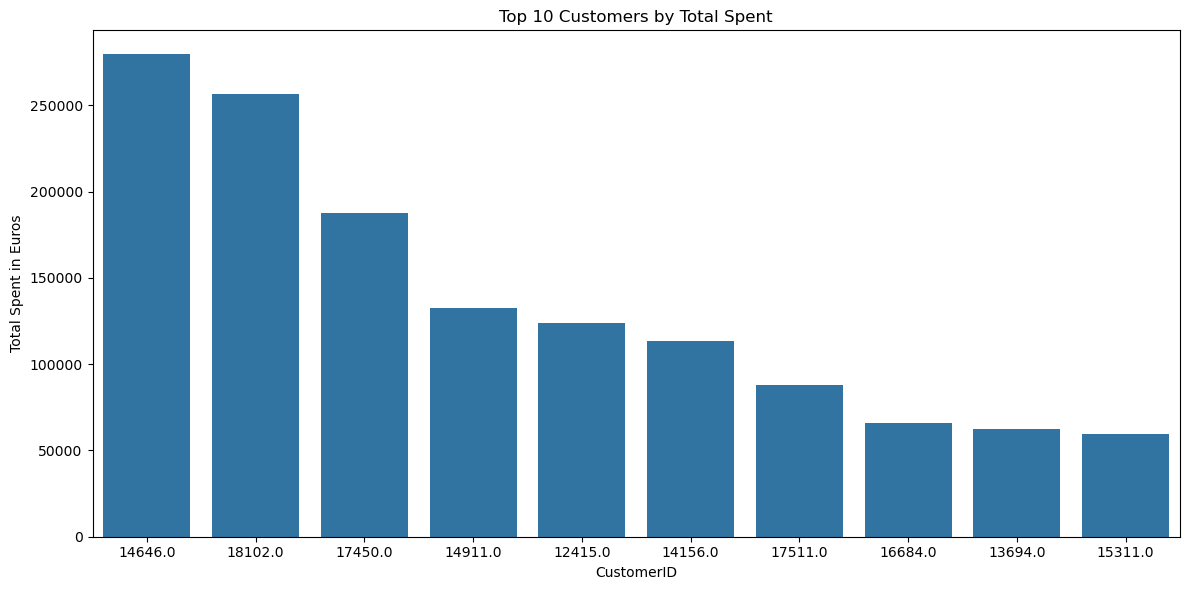

In [33]:
# visual of top 10 customers by total spent
plt.figure(figsize=(12,6))
# set number labels to string for safety
sns.barplot(x=top_customers.index.astype(str), y=top_customers.values)

plt.title('Top 10 Customers by Total Spent')

plt.xlabel('CustomerID')
plt.ylabel('Total Spent in Euros')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
# number of countries
print('Number of Countries:', df['Country'].nunique())
print(df['Country'].unique())

Number of Countries: 37
['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Greece' 'Singapore' 'Lebanon'
 'United Arab Emirates' 'Saudi Arabia' 'Czech Republic' 'Canada'
 'Unspecified' 'Brazil' 'USA' 'European Community' 'Bahrain' 'Malta' 'RSA']


# Analysis - Top Country

In [40]:
# find out what the top country is in total spent
top_country = df.groupby('Country')['TotalSpent'].sum().sort_values(ascending=False).head(5)
print(top_country)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Name: TotalSpent, dtype: float64


# Visualization - Top Country

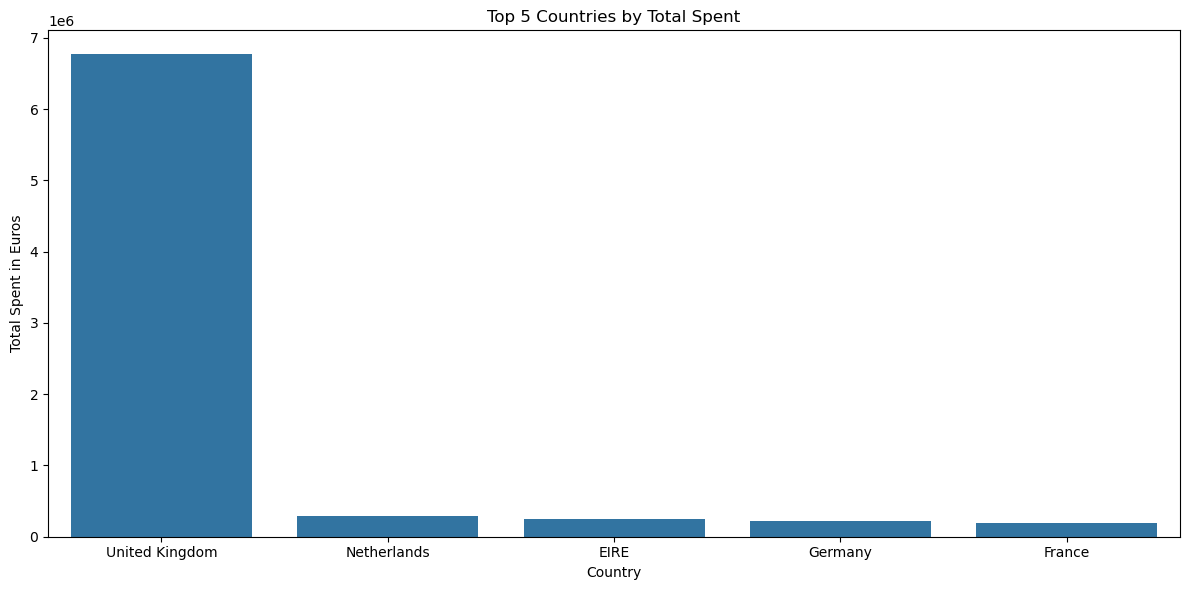

In [41]:
# visual of top 5 countries by total spent
plt.figure(figsize=(12,6))

sns.barplot(x=top_country.index.astype(str), y=top_country.values)

plt.title('Top 5 Countries by Total Spent')

plt.xlabel('Country')
plt.ylabel('Total Spent in Euros')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()